In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
!pip install opencv-python

In [ ]:
from skimage import segmentation, color, feature, morphology
from skimage.filters import threshold_otsu

# Đọc ảnh
img = cv2.imread('Lab5.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Hàm hiển thị nhanh
def plot_res(img1, img2, title1="Original", title2="Result"):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1); plt.imshow(img1, cmap='gray' if len(img1.shape)==2 else None); plt.title(title1); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(img2, cmap='gray' if len(img2.shape)==2 else None); plt.title(title2); plt.axis('off')
    plt.show()

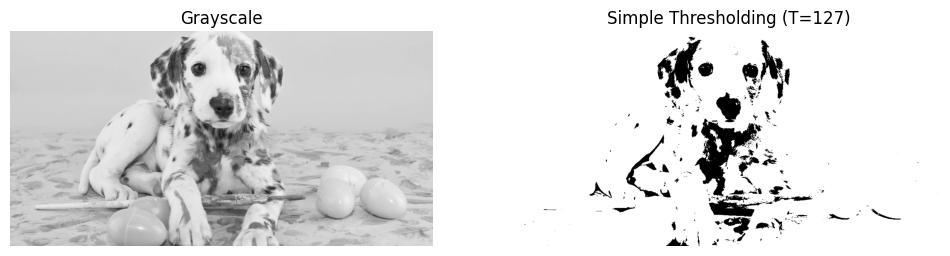

In [ ]:
# Sử dụng ngưỡng cố định (ví dụ: 127)
_, thresh_bin = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
plot_res(img_gray, thresh_bin, "Grayscale", "Simple Thresholding (T=127)")

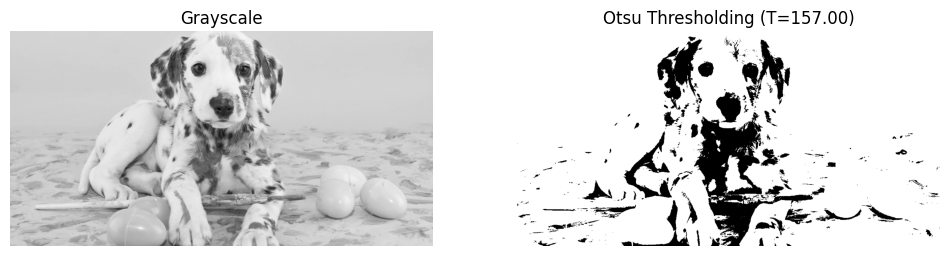

In [ ]:
# Thuật toán Otsu tự tìm ngưỡng tối ưu
val = threshold_otsu(img_gray)
otsu_res = img_gray > val
plot_res(img_gray, otsu_res, "Grayscale", f"Otsu Thresholding (T={val:.2f})")

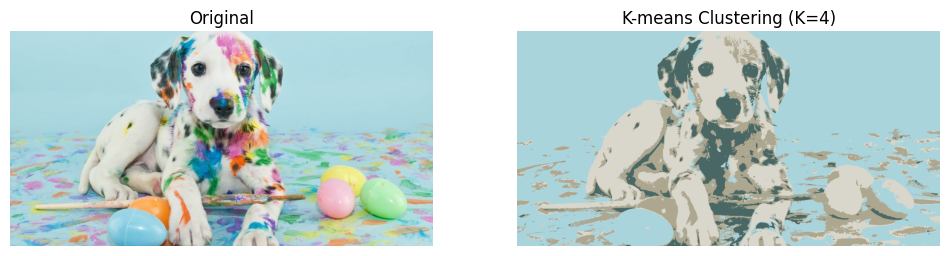

In [ ]:
# Chuẩn bị dữ liệu cho K-means
pixels = img_rgb.reshape((-1, 3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 4 # Số lượng phân vùng màu mong muốn

_, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
kmeans_img = centers[labels.flatten()].reshape(img_rgb.shape)

plot_res(img_rgb, kmeans_img, "Original", f"K-means Clustering (K={k})")

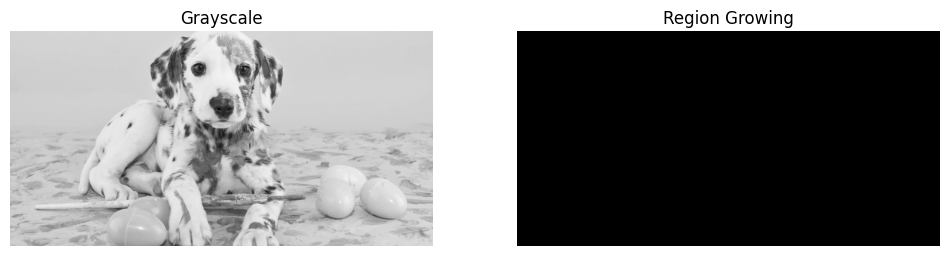

In [ ]:
def simple_region_growing(img, seed, threshold=5):
    h, w = img.shape
    segmented = np.zeros_like(img)
    visited = np.zeros_like(img, dtype=bool)
    stack = [seed]
    start_val = img[seed]

    while stack:
        x, y = stack.pop()
        if visited[y, x]: continue
        visited[y, x] = True

        if abs(int(img[y, x]) - int(start_val)) < threshold:
            segmented[y, x] = 255
            for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < w and 0 <= ny < h:
                    stack.append((nx, ny))
    return segmented

# Chọn seed ở giữa ảnh (có thể thay đổi tọa độ)
seed_point = (img.shape[1]//2, img.shape[0]//2)
reg_grow_res = simple_region_growing(img_gray, seed_point, 15)
plot_res(img_gray, reg_grow_res, "Grayscale", "Region Growing")

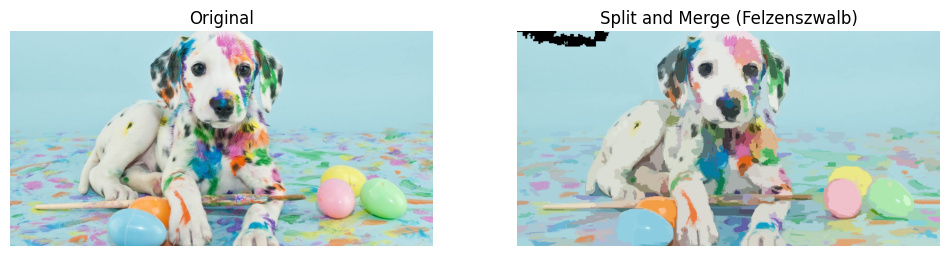

In [ ]:
# Phân đoạn dựa trên vùng (Region-based)
segments = segmentation.felzenszwalb(img_rgb, scale=100, sigma=0.5, min_size=50)
split_merge_res = color.label2rgb(segments, img_rgb, kind='avg')

plot_res(img_rgb, split_merge_res, "Original", "Split and Merge (Felzenszwalb)")

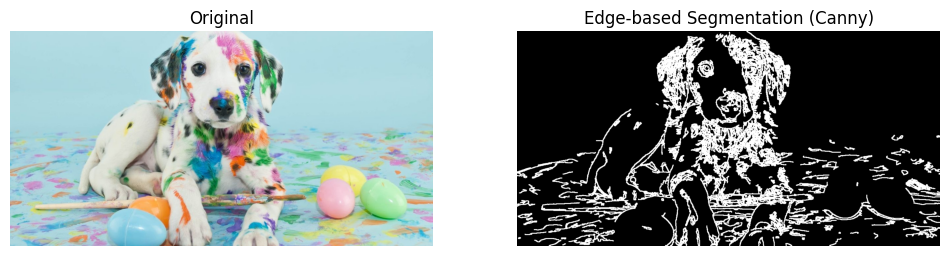

In [ ]:
# Tìm biên bằng Canny
edges = cv2.Canny(img_gray, 50, 150)

# Làm dày biên để tạo vùng kín (Dilation)
kernel = np.ones((3,3), np.uint8)
dilated_edges = cv2.dilate(edges, kernel, iterations=1)

plot_res(img_rgb, dilated_edges, "Original", "Edge-based Segmentation (Canny)")